# HIPAA Breach Data Exploration 
Author: Wendy Lacan

### Dataset Overview
- **Source**: HHS OCR Breach Portal ("Wall of Shame")
- **Filter Applied**: Breach Submission Date between January 9, 2013 - February 25, 2026
- **Rationale**: Focus on post-EHR adoption era (post-HITECH Act) with modern threat vectors
- **Total Records**: 6036 breaches affecting 500+ individuals each

### 1. Data Loading

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

df = pd.read_csv("../data/raw/breach_report.csv")

df.head()

,javax.faces.component.UIPanel@7c06a0cf,State,Covered Entity Type,Individuals Affected,Breach Submission Date,Type of Breach,Location of Breached Information,javax.faces.component.UIPanel@5bb1ef44,Web Description
0,Ko-Kwel Wellness Center,OR,Healthcare Provider,543.0,02/03/2026,Hacking/IT Incident,Network Server,Yes,NaN
1,Chattanooga C.A.R.E.S. d/b/a Cempa Community Care,TN,Healthcare Provider,1341.0,01/30/2026,Unauthorized Access/Disclosure,Other,Yes,NaN
2,Baltimore City Health Department,MD,Healthcare Provider,2597.0,01/28/2026,Hacking/IT Incident,Network Server,Yes,NaN
3,Deschutes County Health Services,OR,Healthcare Provider,1305.0,01/22/2026,Hacking/IT Incident,Network Server,Yes,NaN
4,Bay Area Community Health,CA,Healthcare Provider,9912.0,01/16/2026,Hacking/IT Incident,Network Server,Yes,"The covered entity (CE), Bay Area Community He..."


### 2. Initial Inspection

In [29]:
df.columns = [
    "Name of Covered Entity",
    "State",
    "Covered Entity Type",
    "Individuals Affected",
    "Breach Submission Date",
    "Type of Breach",
    "Location of Breached Information",
    "Business Associate Present",
    "Web Description"
]

In [30]:
df.shape

(6036, 9)

The dataset contains 6036 rows and 9 columns, representing publicly reported healthcare data breaches between January 9, 2013 and February 25, 2026. 

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6036 entries, 0 to 6035
Data columns (total 9 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Name of Covered Entity            6036 non-null   object 
 1   State                             6017 non-null   object 
 2   Covered Entity Type               6031 non-null   object 
 3   Individuals Affected              6035 non-null   float64
 4   Breach Submission Date            6036 non-null   object 
 5   Type of Breach                    6036 non-null   object 
 6   Location of Breached Information  6036 non-null   object 
 7   Business Associate Present        6036 non-null   object 
 8   Web Description                   5828 non-null   object 
dtypes: float64(1), object(8)
memory usage: 424.5+ KB


### 3. Missing Value Analysis

In [32]:
# find all missing values, count them per column, 
# show columns ordered by how many missing values they have from most to least
df.isna().sum().sort_values(ascending=False)

Web Description                     208
State                                19
Covered Entity Type                   5
Individuals Affected                  1
Name of Covered Entity                0
Breach Submission Date                0
Type of Breach                        0
Location of Breached Information      0
Business Associate Present            0
dtype: int64

### 4. Data Cleaning

#### 4.1 Normalizing Column Names

In [33]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)
df.columns

Index(['name_of_covered_entity', 'state', 'covered_entity_type',
       'individuals_affected', 'breach_submission_date', 'type_of_breach',
       'location_of_breached_information', 'business_associate_present',
       'web_description'],
      dtype='object')

In [34]:
df = df.dropna(subset=['individuals_affected'])

In [35]:
df['individuals_affected'] = df['individuals_affected'].astype(int)

Individuals Affected is float64 when it shouldn't because one of the entries has a missing value. Since it was only one row, it was dropped for cleaner analysis. 

#### 4.2 Type Conversion

In [36]:
df['breach_submission_date'] = pd.to_datetime(
    df['breach_submission_date'], 
    errors='coerce'
)

In [37]:
# verify no date parsing failures
df['breach_submission_date'].isna().sum()

np.int64(0)

In [38]:
df['year'] = df['breach_submission_date'].dt.year

In [39]:
df['month'] = df['breach_submission_date'].dt.month

Extracting the year allows for temporal trend analysis. This will help identify if breach frequency is increasing over time which is a key indicator of evolving cybersecurity risk in healthcare

#### 4.3 Territory State Imputation

In [40]:
territory_map = {
    "La Liga Puertorriquena Contra El Cancer DBA Hospital Oncológico": "PR",
    "Oficina Medica": "PR",
    "Guam Seventh-Day Adventist Clinic": "GU",
    "Hospital Auxilio Mutuo": "PR",
    "Frederiksted Health Care, Inc.": "VI",
    "Modern Cardiology Associates": "PR",
    "Doctors' Center Hospital": "PR",
    "Laboratorio Clinico Toledo": "PR",
    "Laboratorio Clínico Caparros": "PR",
    "Servicios de Salud Primarios de Barceloneta, Inc. ": "PR",
    "Intramural Practice Plan - Medical Sciences Campus - University of Puerto Rico": "PR",
    "Bayamon Medical Center Corp.": "PR",
    "Puerto Rico Women And Children's Hospital, LLC": "PR",
    "Farmacia La Amistad Inc.": "PR",
    "Inmediata Health Group": "PR",
    "Inspira Behavioral Care, Corp": "PR",
    "Metro Santurce, Inc. d/b/a Hospital Pavia Santurce and Metro Hato Rey, Inc. d/b/a Hospital Pavia Hato Rey": "PR",
    "Triple-S Advantage, Inc.": "PR",
    "Puerto Rico Department of Heatlh - Medicaid Program": "PR"
}

for name_fragment, state_code in territory_map.items():
    mask = df['name_of_covered_entity'].str.contains(name_fragment, case=False, na=False)
    df.loc[mask, 'state'] = state_code

19 records had missing state values, all belonging to U.S. territories, primarily Puerto Rico, Guam, and the US Virgin Islands. 


To preserve geographic information while maintaining consistency with U.S. regional codes, Puerto Rico will be labeled **PR**, Guam will be labeled as **GU**, and the U.S. Virgin Islands will be labeled as **VI**. They were manually mapped based on entity name and known location. This approach avoids dropping valid records and preserves useful geographic information for future analysis.

### 5. Univariate Analysis

#### 5.1 Individuals Affected Distribution

In [41]:
df[['individuals_affected']].describe()

,individuals_affected
count,6.035000e+03
mean,1.023541e+05
std,1.147525e+06
min,5.000000e+02
25%,1.301500e+03
50%,4.013000e+03
75%,1.989550e+04
max,7.880000e+07


**Median**: 4,013
**Mean**: 102,354
**Max**: 78,800,000
**Min**: 500

The large difference between the mean and median indicates the dataset is extremely right-skewed due to a small number of mega-breaches. For example, the largest single breach affected 78.8 million individuals which is 7,795,987 more than the median (4013). 

#### 5.2 Temporal Distribution

In [42]:
print(f"Date Range: {df['breach_submission_date'].min()} to {df['breach_submission_date'].max()}")
print(f"Total Breaches: {len(df)}")
print(f"\nBreaches by Year:")
print(df['year'].value_counts().sort_index())

Date Range: 2013-01-02 00:00:00 to 2026-02-03 00:00:00
Total Breaches: 6035

Breaches by Year:
year
2013    276
2014    314
2015    270
2016    328
2017    358
2018    369
2019    511
2020    663
2021    715
2022    719
2023    741
2024    553
2025    207
2026     11
Name: count, dtype: int64


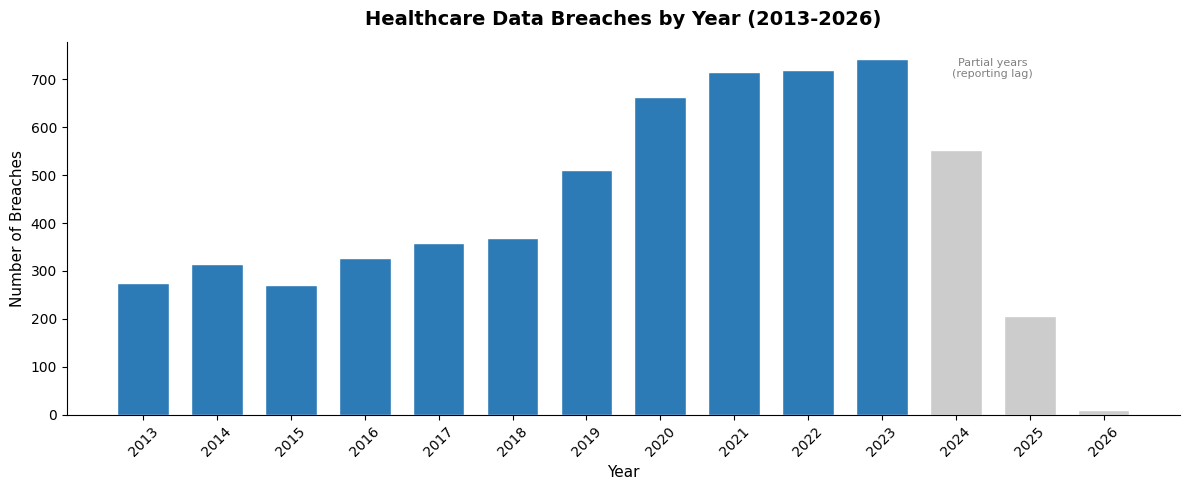

In [43]:
year_counts = df['year'].value_counts().sort_index()
partial_years = [2024, 2025, 2026]

fig, ax = plt.subplots(figsize=(12,5))

ax.bar(
    year_counts.index,
    year_counts.values,
    color=['#cccccc' if y in partial_years else '#2c7bb6' for y in year_counts.index],
    edgecolor='#ffffff',
    width=0.7
)

ax.set_title('Healthcare Data Breaches by Year (2013-2026)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Number of Breaches', fontsize=11)
ax.set_xticks(year_counts.index)
ax.set_xticklabels(year_counts.index, rotation=45)

ax.text(2024.5, year_counts.max() * 0.95, 'Partial years\n(reporting lag)',
        fontsize=8, color='gray', ha='center')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

2024-2026 counts are partial and should not be interpreted as a true decline. Cases within the last 24 months are still under investigation by the Office of Civil Rights. 

#### 5.3 Categorical Fields

In [44]:
print("Covered Entity Type")
print("-"*50)
print(df['covered_entity_type'].value_counts())
print(f"\nUnique values: {df['covered_entity_type'].nunique()}")

Covered Entity Type
--------------------------------------------------
covered_entity_type
Healthcare Provider          4369
Business Associate            864
Health Plan                   784
Healthcare Clearing House      13
Name: count, dtype: int64

Unique values: 4


The majority of breaches involve Healthcare Providers (about 72%). 

In [45]:
print("\n")
print("Type Of Breach")
print("-"*50)
print(df['type_of_breach'].value_counts())
print(f"\nUnique values: {df['type_of_breach'].nunique()}")



Type Of Breach
--------------------------------------------------
type_of_breach
Hacking/IT Incident                                                                                    3643
Unauthorized Access/Disclosure                                                                         1431
Theft                                                                                                   615
Loss                                                                                                    167
Improper Disposal                                                                                        93
Other                                                                                                    37
Theft, Unauthorized Access/Disclosure                                                                    16
Loss, Theft                                                                                               6
Loss, Unauthorized Access/Disclosure                 

The "type_of_Breach" column contains multi-value entries stored as a comma-separated string. These will need to be split and transformed into binary indicator variables. 

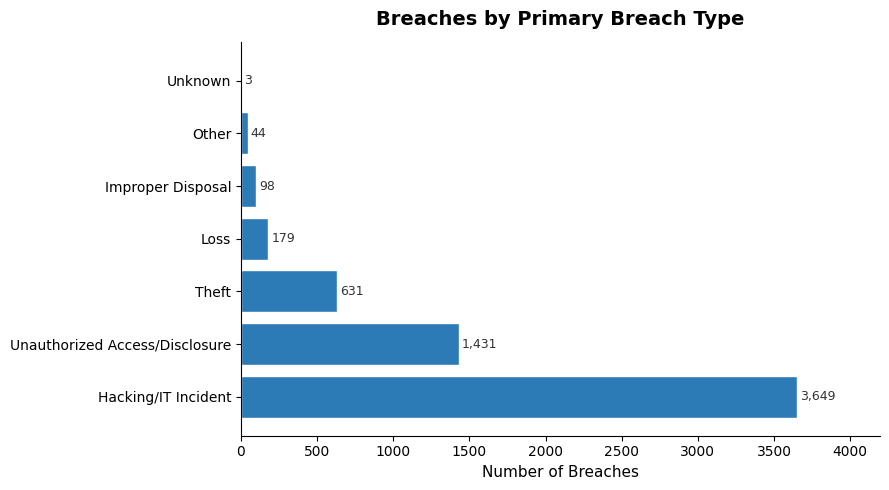

In [46]:
def primary_breach_type(val):
    if pd.isna(val):
        return 'Unknown'
    types = [t.strip() for t in val.split(',')]
    return types[0]

breach_counts = df['type_of_breach'].apply(primary_breach_type).value_counts()

fig, ax = plt.subplots(figsize=(9,5))

bars = ax.barh(
    breach_counts.index,
    breach_counts.values,
    color='#2c7bb6',
    edgecolor='#ffffff'
)

for bar, count in zip(bars, breach_counts.values):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{count:,}', va='center', fontsize=9, color='#333333')
    
ax.set_title('Breaches by Primary Breach Type', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Number of Breaches', fontsize=11)
ax.set_xlim(0, breach_counts.max() * 1.15)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

Multi-type breach entries are mapped to their primary listed type for visualization. 

In [47]:
print("Location of Breached Information")
print("-"*50)
print(df['location_of_breached_information'].value_counts())
print(f"\nUnique values: {df['location_of_breached_information'].nunique()}")

Location of Breached Information
--------------------------------------------------
location_of_breached_information
Network Server                                                                                                               2498
Email                                                                                                                        1455
Paper/Films                                                                                                                   724
Electronic Medical Record                                                                                                     269
Laptop                                                                                                                        240
                                                                                                                             ... 
Desktop Computer, Other Portable Electronic Device, Paper/Films                                        

The "type_of_breached_information" column contains multi-value entries stored as comma-separated strings, representing multiple locations involved in a single breach incident. Although there are 88 unique values, a lot of these are combinations of the same categories like the structure observed in "type_of_breach".

In [48]:
print("\n")
print("Business Associate Present")
print("-"*50)
print(df['business_associate_present'].value_counts())



Business Associate Present
--------------------------------------------------
business_associate_present
No     4198
Yes    1837
Name: count, dtype: int64


Approximately 30% of reported breaches involve a business associate.

### 6. Data Quality Checks

#### 6.1 Duplicate Detection

In [49]:
print(f"Duplicate Rows: {df.duplicated().sum()}")

duplicates = df.groupby(['name_of_covered_entity', 'breach_submission_date']).size()
print(f"\nSame entity + same date: {(duplicates > 1).sum()}")

Duplicate Rows: 0

Same entity + same date: 30


Some organizations reported multiple reported breaches on the same day or one breach involved multiple breach types or locations. 

#### 6.2 Missing State Analysis

In [50]:
print("Remaining missing states:", df['state'].isna().sum())

Remaining missing states: 0


All 19 missing state values were resolved in section 4.3 by manual territory mapping.

### 7. Export Cleaned Data

In [51]:
df.to_csv('../data/processed/breach_report_cleaned.csv', index=False)
print(f"Saved cleaned dataset: {df.shape[0]} rows, {df.shape[1]} columns")

Saved cleaned dataset: 6035 rows, 11 columns
